# Lexos Bootstrap Consensus Tree Tutorial

We'll begin by importing some data and creating a DTM.

In [1]:
from lexos.dtm import DTM
from lexos.io.loader import Loader
from lexos.tokenizer import Tokenizer

# Load some text files and set their names
files = [
    "FilesToUse/Poe_FallOfHouseUsher_1839.txt",
    "FilesToUse/Lippard_BelOfPrairieEden.txt",
    "FilesToUse/Irving_RipVanWInkle.txt",
    "FilesToUse/HenryWP_ThePirate.txt",
]
loader = Loader()
loader.load(files)
loader.names = ["Poe", "Lippard", "Irving", "Henry"]

# Tokenize the loaded documents
tokenizer = Tokenizer()
docs = list(tokenizer.make_docs(texts=loader.texts))
labels = loader.names

print(f"Loaded {len(docs)} documents with labels: {labels}")

# Create a Document-Term Matrix (DTM)
dtm = DTM()
dtm(docs=docs, labels=labels)

print(f"DTM created with {dtm.to_df().shape[1]} documents and {dtm.to_df().shape[0]} unique terms.")

Loaded 4 documents with labels: ['Poe', 'Lippard', 'Irving', 'Henry']
DTM created with 4 documents and 7727 unique terms.


### Generating the Bootstrap Consensus Tree (BCT): Visualizing Textual Relationships

Now for the exciting part: generating and displaying your Bootstrap Consensus Tree! This tree visually represents the relationships between your documents based on the numerical data in our DTM.

A **Bootstrap Consensus Tree** is particularly robust because it doesn't just build one tree. Instead, it builds many, many trees by randomly sampling portions of your DTM, and then it finds the "consensus" – the most consistently appearing relationships across all those individual trees.

When we create the BCT, we need to tell it how to build and combine these trees. Here are the key parameters you can adjust:

* **`doc_term_matrix`**: This is our "linguistic spreadsheet" (`dtm`) that we created in the previous step. It's the essential input for the tree.

* **`distance_metric`**: This tells the tree how to measure the "distance" or dissimilarity between your documents. Shorter distances mean more similar documents.
    * **`"euclidean"`**: Think of this as the "straight-line" distance between two points on a graph. It's good for general comparisons but can be sensitive to the overall length of documents (longer documents might naturally have larger term counts, increasing their "distance").
    * **`"cosine"`**: Imagine each document as an arrow pointing in a specific linguistic "direction." Cosine similarity measures how much these arrows point in the same direction. If they point almost identically, the documents are very similar, even if one document is much longer than another. This is often an excellent choice for text analysis since it focuses less on raw word counts.
    * **`"cityblock"`** (also called Manhattan distance): Imagine moving on a city grid where you can only go along streets (no diagonal shortcuts). This distance is the sum of the absolute differences for each term between two documents. Useful when the individual differences in term counts are important.

* **`linkage_method`**: Once we've measured distances, this method determines how individual documents (or existing clusters of documents) are joined together to form larger branches and clusters in the tree.
    * **`"average"`**: When combining two clusters, this method considers the average distance between *all* pairs of documents in the two clusters. Tends to produce well-balanced clusters.
    * **`"single"`**: Joins clusters based on the *closest* pair of documents between them. This can sometimes lead to "chaining," where documents connect one after another.
    * **`"complete"`**: Joins clusters based on the *farthest* pair of documents between them. This tends to produce more compact, spherical clusters, ensuring all documents within a cluster are relatively similar.
    * **`"ward"`**: This method aims to minimize the increase in "variance" (or spread) within clusters when they are merged. It tries to make clusters that are as "tight" and internally similar as possible.

* **`cutoff`**: This is a confidence threshold. As mentioned, the BCT is built from many individual "bootstrap" trees. A `cutoff` of `0.5` (which means 50%) means that a specific grouping of documents (a branch on the tree) must appear in at least 50% of all the trees generated during the `iterations` to be considered reliable enough to show up in the final consensus tree.
    * **Higher `cutoff` values (e.g., 0.7 or 0.8)**: Will result in a "sparser" tree, showing only the most robust and consistent relationships.
    * **Lower `cutoff` values (e.g., 0.3)**: Will show more relationships, but some of these might be less statistically reliable.

* **`iterations`**: This is the number of "bootstrap resampling" rounds. In each round, `lexos` takes a random 80% sample of the terms (columns) from your DTM and builds a tree from that sample.
    * **More iterations (e.g., 100, 1000)**: Make the consensus tree more statistically reliable and representative of the underlying relationships in your texts, as it averages out more variations. However, it will take longer to compute.
    * **Fewer iterations (e.g., 10, 20)**: Are good for quick testing or initial explorations.
    * *Recommendation*: For final research results, `100` (the default in the `BCT` class) or higher is often recommended if computation time allows. For this tutorial, we'll use `10` to keep it fast.

* **`replace`**: This relates to how the terms are sampled during each iteration.
    * **`"with"`**: Means a term column can be selected multiple times within a single 80% sample (allows for more randomness).
    * **`"without"`**: Means each term column can only be selected once per 80% sample (more stable).
    * *Recommendation*: `"without"` is generally suitable for DTMs as it ensures each unique term contributes uniquely within a sample.

* **`doc_labels`**: This is simply the list of descriptive names for your documents (e.g., "Poe", "Lippard") that we defined earlier. These will appear as the leaves (endpoints) on your tree.

* **`text_color`**: Sets the color for all text on the plot (axis labels, branch lengths, and document labels). You can use "rgb(R, G, B)" format. For example:
    * `"rgb(0, 0, 0)"`: Black
    * `"rgb(255, 0, 0)"`: Red

* **`style`**: Sets the style of the dendrogram. The default style is "rectangular". Other styles are "fan" and "circular", but these are under development and do not yet produce usable results.

* **`showfig`**: Controls whether the generated tree figure is displayed directly in this Jupyter Notebook cell.
    * **`True`**: The tree will appear right below the code cell.
    * **`False`**: The tree will not be shown immediately. This is useful if you just want to save the figure to a file without displaying it.

Let's generate our first Bootstrap Consensus Tree!

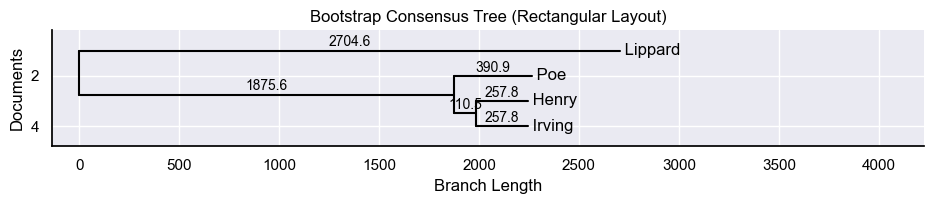

In [6]:
# Import the BCT class for Bootstrap Consensus Tree
from lexos.cluster.bootstrap_consensus2 import BCT

# Create an instance of the BCT object
bct = BCT()

# Generate the Bootstrap Consensus Tree.
# Experiment with the parameters below!
fig = bct(
    doc_term_matrix=dtm,
    distance_metric="euclidean", # Try "cosine" for stylistic comparisons, or "cityblock"
    linkage_method="average",    # Try "ward" for compact clusters, or "complete"
    cutoff=0.5,                  # Only show relationships present in at least 50% of bootstrap trees
    iterations=10,               # Set higher (e.g., 100) for more reliable results, lower for faster testing
    replace="without",           # Do not repeat terms in each sample
    doc_labels=labels,           # Use the labels we defined for our documents
    text_color="rgb(0, 0, 0)",   # Set the text color to black
    layout="rectangular",         # Alternatively, use "fan"
    showfig=True,                # Display the figure in the notebook
    title="Bootstrap Consensus Tree (Rectangular Layout)"  # Set a title for the dendrogram
)

# This line ensures the figure is shown, even if showfig was set to False.
#fig.show()

### 6. Interpreting Your Bootstrap Consensus Tree

Now that you've generated the tree, let's talk about how to read it!

The tree you see is a **dendrogram**, a type of tree diagram that shows hierarchical clustering.

* **Leaves (Document Labels)**: At the very end of each branch, you'll see your document labels (Poe, Lippard, Irving, Henry). These are your individual texts.
* **Branches and Nodes (Clusters)**: The lines that connect documents and other branches represent clusters. When branches merge, it means the documents or clusters they represent are being grouped together.
* **Branch Lengths (Dissimilarity/Distance)**: The horizontal length of a branch indicates the **distance** or **dissimilarity** between the documents or clusters it connects.
    * **Shorter horizontal branches** mean that the documents or clusters are **more similar** to each other based on their linguistic features. They are "closer."
    * **Longer horizontal branches** mean that the documents or clusters are **less similar** to each other. They are "further apart."

**How to Read the Tree:**

Start from the leaves (your document names) and move left towards the root of the tree.
1.  **Closest Relatives:** Look for the first merges. Documents that merge first (i.e., they are connected by a short horizontal branch) are the most similar to each other.
2.  **Broader Groupings:** As you move further left, you'll see larger branches forming, grouping together sets of documents or smaller clusters. These broader groupings represent larger patterns of similarity.

**Example Interpretation (based on typical results for these texts):**

You might observe that "Poe" and "Irving" are clustered together with a relatively short branch length, suggesting a linguistic similarity. Then, perhaps "Henry" joins that cluster, indicating it's somewhat similar to the Poe/Irving group but less so than they are to each other. "Lippard" might be an outlier, joining the main cluster with a much longer branch, indicating it's quite distinct linguistically from the others.

**What Your Tree Might Tell You:**

* **Stylistic Similarities:** Are authors from the same period or literary movement clustering together?
* **Genre Influence:** Do texts of a particular genre (e.g., gothic horror) form a distinct cluster?
* **Thematic Patterns:** If you used POS filtering or focused on specific terms, does the tree reveal groupings based on shared themes or subject matter?

### 7. Customizing Your Visualization: Making the Tree Your Own

The `lexos` BCT uses `matplotlib` to create the plot, which means you have a lot of control over its appearance. While `lexos` sets sensible defaults, you can easily tweak things!

#### Adjusting Font Size

 You can adjust the default font size for your plots using `plt.rcParams.update`. This needs to be run *before* you generate the tree, or you can re-run the tree generation cell after making this change.

In [3]:
# Uncomment the line below and change the number to adjust font size.
# Try 10, 12, or even higher to see the effect.
# plt.rcParams.update({'font.size': 12}) # Set default font size for all matplotlib plots

# You would then re-run the BCT generation cell (Section 5) to see the change.

#### Adjusting Figure Size

If your tree has many documents or long labels, it might feel cramped. You can make the overall figure wider or taller to give it more space. This is done by setting the `w` (width) and `h` (height) parameters in `plt.gcf().set_size_inches()`. This adjustment is already part of the `lexos` code for the tree, but you can override it if you need a specific size.

Currently, the `lexos` BCT automatically adjusts height based on the number of documents. The default width is 9.5 inches. You can modify these:

In [4]:
# You can manually adjust the figure size *after* the tree has been generated
# but *before* you save or show it, if the automatic sizing isn't perfect for you.

# Example: Make the figure 12 inches wide and 8 inches tall
# fig.set_size_inches(w=12, h=8)

# Then you would call fig.show() again or save it.

### 8. Saving Your Tree: Keeping Your Results

Once you're happy with your Bootstrap Consensus Tree, you'll likely want to save it as an image file for reports, presentations, or simply for your records.

The `bct.save()` method allows you to do this easily. Just provide a file name, and it will save the image in the same directory where your Jupyter Notebook is located. You can choose different file formats by changing the extension (e.g., `.png`, `.jpg`, `.pdf`, `.svg`). PNG is generally a good choice for web or documents, while SVG provides a scalable vector graphic useful for high-quality printing.

In [5]:
# bct.save("bct_test_result.png")

# print("Tree saved as 'my_bct_analysis_result.png' in your notebook's directory.")

### 9. Troubleshooting 

**"My tree looks blank or empty!"**
* **Check `cutoff`:** If your `cutoff` is too high (e.g., 0.9 or 1.0), it might be too strict, and no common groupings meet that threshold. Try lowering it (e.g., to 0.5 or 0.3).
* **Check `iterations`:** If `iterations` is very low (e.g., 1 or 2), there might not be enough "sampling" to find a stable consensus. Increase it.
* **Verify DTM:** Ensure your `dtm` was created successfully and contains terms. If your documents are very short or very similar, the DTM might be sparse.

**"My documents don't cluster the way I expected!"**
* **Experiment with `distance_metric` and `linkage_method`**: Different metrics and methods reveal different aspects of similarity. `"cosine"` often works well for stylistic analysis of texts. `"ward"` or `"average"` are generally good linkage methods.
* **Adjust DTM pre-processing**: Try different combinations of `stop_words`, `lemmatize`, `pos_filter`, `min_freq`, and `ngrams`. The choice of "terms" is paramount to the relationships you uncover. For example, if you're interested in character interactions, perhaps filtering for proper nouns and verbs would be revealing.
